# Image Segmentation and Clustering

## K-Means Clustering

Image segmentation using K-Means involves clustering the pixels of the image based on their colors. This often results in an image where different regions are represented by different colors, indicating different segments or clusters.

Here's a step-by-step plan of how we'll achieve this:

- Load the image using OpenCV.
- Convert the image from BGR to RGB (as OpenCV loads images in BGR format).
- Flatten the image to get all the pixels.
- Apply K-Means clustering to cluster the pixels based on color.
- Reshape the flattened image back to its original shape.
- Display the segmented image.

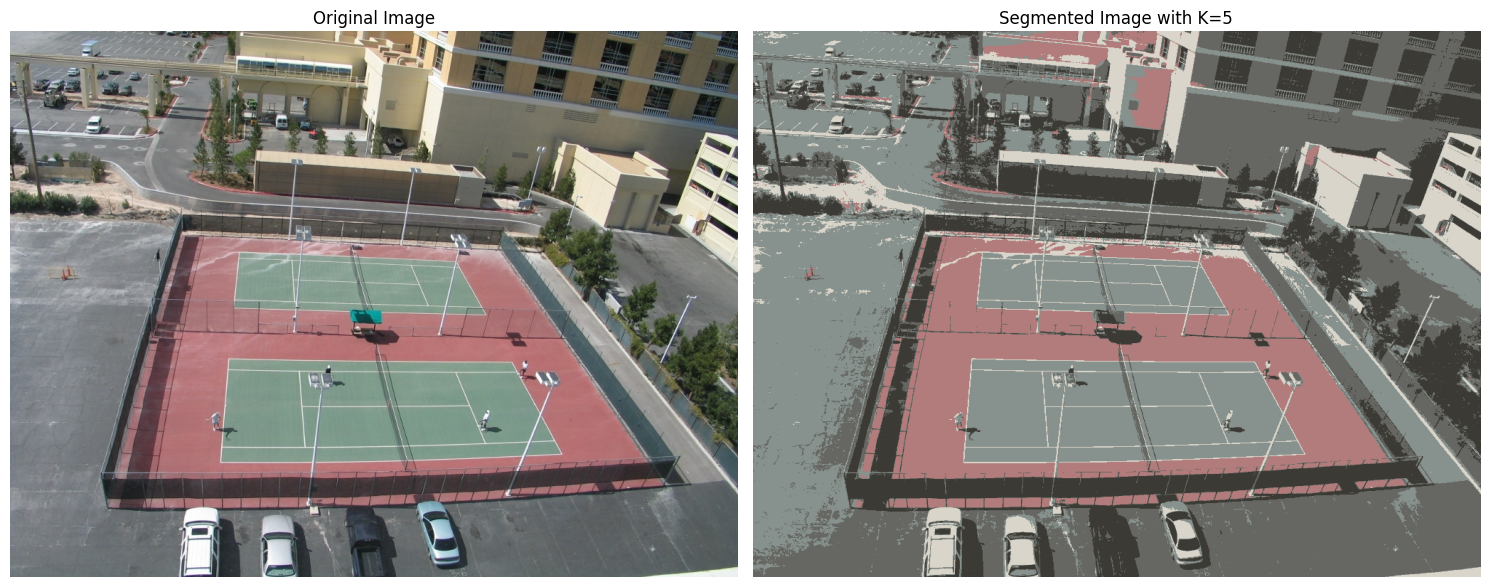

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread('data/tennis_court2.jpg')

# Convert the image from BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Flatten the image
pixels = img_rgb.reshape((-1, 3))

# Apply K-Means clustering
k = 5  # Number of clusters
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixels.astype(np.float32), k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Convert centers to integers
centers = np.uint8(centers)

# Map the labels to the centers
segmented_image = centers[labels.flatten()]

# Reshape the segmented image to its original shape
segmented_image = segmented_image.reshape(img_rgb.shape)

# Plotting the original and segmented images
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(segmented_image)
axes[1].set_title('Segmented Image with K={}'.format(k))
axes[1].axis('off')

plt.tight_layout()
plt.show()


### K-Means Clustering Parameters

The `cv2.kmeans` function is called as follows:
```python
_, labels, centers = cv2.kmeans(pixels.astype(np.float32), k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
```
Here is a breakdown of its parameters, with reference to the values used in the code:

1.  `data`: `pixels.astype(np.float32)` 
    - The input data for clustering. It must be of type `np.float32`, with each feature in a separate column.
2.  `K`: `k` (set to 5)
    - The desired number of clusters.
3.  `bestLabels`: `None`
    - This is an output parameter. When `None` is passed, it initializes an array that will be filled with the cluster index for each data point.
4.  `criteria`: `(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)`
    - The termination criteria for the iterative algorithm. The algorithm stops when either of the following conditions is met:
        - `cv2.TERM_CRITERIA_MAX_ITER`: A maximum of **100** iterations is reached.
        - `cv2.TERM_CRITERIA_EPS`: The cluster centers move by less than **0.2**.
5.  `attempts`: `10`
    - The number of times the K-Means algorithm is run with different initial centroid selections. The final result will be the one with the best compactness.
6.  `flags`: `cv2.KMEANS_RANDOM_CENTERS`
    - Specifies how the initial cluster centers are chosen. In this case, they are selected randomly from the data points.

## Mean Shift Algorithm

The Mean Shift algorithm is a non-parametric clustering technique that can be applied to image segmentation. It works by iteratively shifting points to the mode (densest region) of a distribution. For image segmentation, Mean Shift considers the spatial and color information of the image.

The process typically involves:

- Convert the image to the CIELab color space (Mean Shift often performs better in this space than RGB).
- Apply Mean Shift segmentation.
- Display the results.

**Note:** The CIELab color space, often referred to simply as Lab, is a color space defined by the International Commission on Illumination (abbreviated as CIE for its French name, Commission Internationale de l'Éclairage). It is designed to be perceptually uniform, meaning that the perceptual difference between colors is consistent across the color space.

Here's a breakdown of its components:

1. **L** (Luminance or Lightness): 
    - Represents the lightness of the color.
    - Ranges from 0 (black) to 100 (white).

2. **a** (from green to red): 
    - A value of a > 0 indicates a movement towards red.
    - A value of a < 0 indicates a movement towards green.
  
3. **b** (from blue to yellow): 
    - A value of b > 0 indicates a movement towards yellow.
    - A value of b < 0 indicates a movement towards blue.

It's common to use the CIELab color space in image processing because of its perceptual uniformity. For example, when comparing the difference between two colors, the Euclidean distance between their Lab representations can be a good approximation of the perceptual difference between them. This isn't always the case in other color spaces like RGB.

Number of clusters (unique colors) found by Mean Shift: 40897


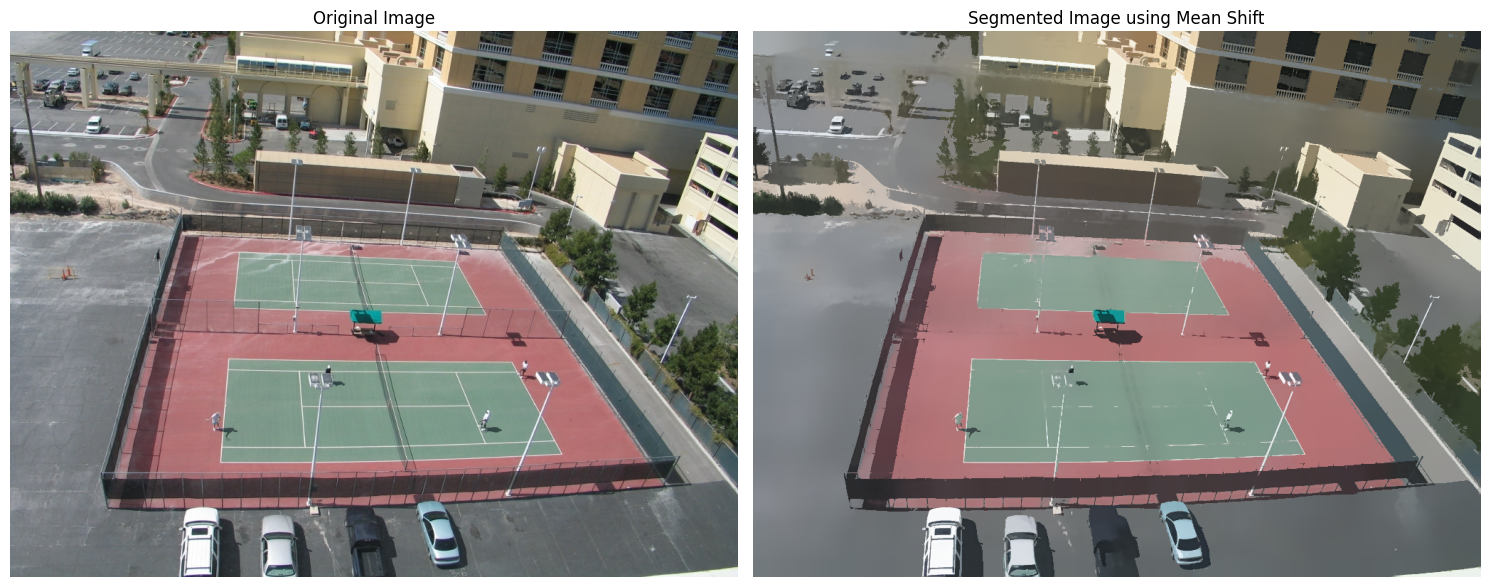

In [ ]:
# Load the image
img = cv2.imread('data/tennis_court2.jpg')

# Convert the image to LAB color space
img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)

# Flatten the image
pixels_lab = img_lab.reshape((-1, 3))

# Apply Mean Shift
# Define the spatial window radius 'sp' and color window radius 'sr'
sp = 20
sr = 40
# Apply Mean Shift without the criteria parameter
mean_shift_result = cv2.pyrMeanShiftFiltering(img, sp, sr)

# Print the number of clusters created by mean shift.
# Convert the result to a 2D array with shape (H*W, 3)
mean_shift_labels = mean_shift_result.reshape((-1, 3))
# Find unique colors in the result (each unique color can be considered a cluster)
unique_clusters = np.unique(mean_shift_labels, axis=0)
print('Number of clusters (unique colors) found by Mean Shift:', len(unique_clusters))

# Convert the result back to RGB for display
mean_shift_result_rgb = cv2.cvtColor(mean_shift_result, cv2.COLOR_BGR2RGB)

# Plotting the original and segmented images
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(mean_shift_result_rgb)
axes[1].set_title('Segmented Image using Mean Shift')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Mean Shift Filtering Parameters

The `cv2.pyrMeanShiftFiltering` function is called as follows:
```python
mean_shift_result = cv2.pyrMeanShiftFiltering(img, sp, sr)
```
Here is a breakdown of its parameters, with reference to the values used in the code:

1.  `src`: `img`
    - The input image, which must be an 8-bit, 3-channel image.

2.  `sp`: `20`
    - The spatial window radius. This parameter defines the radius of the search window in the spatial domain. A larger value will mean that more distant pixels are considered in the mean shift calculation, potentially leading to larger segments but also slower performance.

3.  `sr`: `40`
    - The color window radius. This parameter defines the radius of the search window in the color domain. A larger value will cause colors that are further apart to be grouped into the same segment, leading to fewer, more dominant color regions.

The algorithm works by iterating through each pixel of the image and, for each pixel, defining a window of radius `sp` around it. It then computes the mean color value within that window (for pixels whose color is within the `sr` radius of the current pixel's color) and shifts the center of the window to that mean. This process is repeated until the window's center converges, and the color of the original pixel is then set to the color of the converged window's center.


## Watershed Algorithm

The Watershed algorithm is a classic image segmentation method based on topography. It works by viewing the grayscale image as a topographic surface where light pixels are high elevations and dark pixels are low elevations. The algorithm then floods this surface from its minima (i.e., the dark regions) and builds barriers (or watershed lines) at places where flooding from different sources meets.

To apply the Watershed algorithm effectively, you often need to define markers, which are areas that are sure to be foreground or background. The quality of segmentation highly depends on the accuracy of these markers.

For this example:

- We'll convert the image to grayscale.
- Use Otsu's thresholding to get a binary mask.
- Define sure foreground and sure background regions.
- Use the distance transform to determine the uncertain region.
- Apply the Watershed algorithm.
- Display the results.

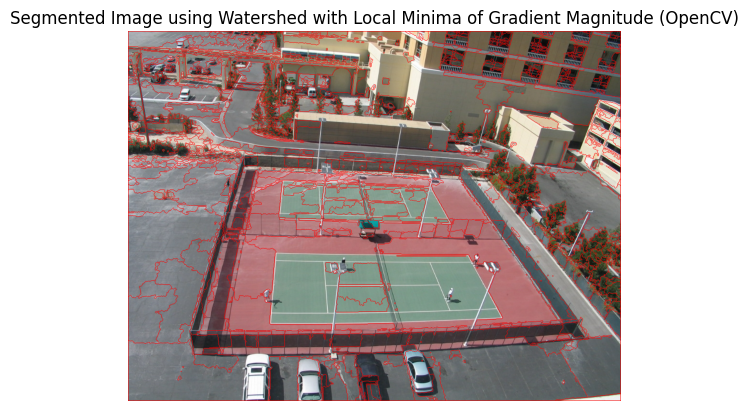

In [9]:
# Load the image
img = cv2.imread('data/tennis_court2.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Calculate the gradient magnitude
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)

# Convert the gradient magnitude to 8-bit
gradient_magnitude_8bit = np.uint8(255 * gradient_magnitude / gradient_magnitude.max())

# Compute the local minima using morphological opening
local_minima = cv2.morphologyEx(gradient_magnitude_8bit, cv2.MORPH_OPEN, kernel=np.ones((5,5), np.uint8))

# Identify the local minima by subtracting the opened image from the original gradient magnitude
local_minima = gradient_magnitude_8bit - local_minima

# Threshold to binary image to get markers
_, markers = cv2.threshold(local_minima, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Label the markers
_, markers = cv2.connectedComponents(markers)

# Convert the markers to 32-bit int for the Watershed algorithm
markers = markers.astype(np.int32)

# Apply the Watershed algorithm
cv2.watershed(img, markers)

# Mark watershed boundaries in red
img[markers == -1] = [0, 0, 255]

# Convert the result back to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(img_rgb)
plt.title('Segmented Image using Watershed with Local Minima of Gradient Magnitude (OpenCV)')
plt.axis('off')
plt.show()

### Watershed Algorithm Parameters

The `cv2.watershed` function is called as follows:
```python
cv2.watershed(img, markers)
```
Here is a breakdown of its parameters, with reference to the values used in the code:

1.  `image`: `img`
    - This is the input image for segmentation. It must be an 8-bit, 3-channel image (like a standard color image).

2.  `markers`: `markers`
    - This is a critical input/output parameter. It is a single-channel, 32-bit integer array (`np.int32`) of the same size as the input image.
    - **On input**, it contains the initial markers for different regions.
        - Pixels with a value of `0` are considered "unknown" and are the ones the algorithm will segment.
        - Pixels with positive integer values (`1`, `2`, `3`, etc.) are treated as seeds for different regions. These are the starting points for the "flooding" process.
    - **On output**, the `markers` array is modified in place:
        - The "unknown" pixels (`0`) are assigned the label of the region they belong to.
        - Pixels at the boundaries between regions (the watershed lines) are marked with `-1`.
